<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Fraud-Detection-with-Federated-Learning/blob/main/New_dataset_AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [3]:
import os

os.environ['KAGGLE_USERNAME'] = "devindithathsara "
os.environ['KAGGLE_KEY'] = "29219555"

print("⏳ Downloading dataset from Kaggle...")
!pip install -q kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip -d dataset/

import pandas as pd
from sklearn.preprocessing import StandardScaler

print("⏳ Loading and preprocessing dataset...")
df = pd.read_csv('dataset/creditcard.csv')

# scalling time and amount (another things ara scaling before from PCA)
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

#remove old features
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# X (features) , y (labels)
X = df.drop('Class', axis=1).values
y = df['Class'].values

print(f"✅ Dataset ready! Total transactions: {len(df)}")

⏳ Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 251MB/s]

Archive:  creditcardfraud.zip
  inflating: dataset/creditcard.csv  
⏳ Loading and preprocessing dataset...
✅ Dataset ready! Total transactions: 284807


Non-IID Data Partitioning using Dirichlet Distribution

In [4]:
NUM_CLIENTS = 12
alpha = 0.5 # The lower the value, the greater the heterogeneity of data between banks.

def dirichlet_split(X, y, num_clients, alpha):
    data_per_client = [[] for _ in range(num_clients)]
    labels = np.unique(y)

    for label in labels:
        idx = np.where(y == label)[0]
        np.random.shuffle(idx)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        split_idx = np.split(idx, proportions)

        for i in range(num_clients):
            data_per_client[i].extend(split_idx[i])

    clients_data = {}
    for i in range(num_clients):
        client_idx = data_per_client[i]

        clients_data[i] = {"X": X[client_idx], "y": y[client_idx]}
    return clients_data

In [5]:
# divide like Non-IID data to 12 banks
raw_clients_data = dirichlet_split(X, y, NUM_CLIENTS, alpha)

#  Train/Test split (all the data of all the banks)
clients_final_data = {}
for i in range(NUM_CLIENTS):
    X_c, y_c = raw_clients_data[i]["X"], raw_clients_data[i]["y"]
    # 80% Train, 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
    clients_final_data[i] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }

print("✅ Data partitioned into 12 banks using Non-IID Dirichlet Split.")

✅ Data partitioned into 12 banks using Non-IID Dirichlet Split.


In [6]:
# Analysis
def analyze_clients(data_to_analyze):
    print("\nClient Data Distribution (Non-IID Analysis):\n")
    print(f"{'Bank':<10} | {'Total':<10} | {'Fraud':<10} | {'Fraud %':<10}")
    print("-" * 50)
    for client_id in range(NUM_CLIENTS):
        y_client = raw_clients_data[client_id]["y"]
        total = len(y_client)
        fraud = np.sum(y_client == 1)
        fraud_pct = (fraud / total) * 100
        print(f"Bank {client_id+1:<5} | {total:<10} | {fraud:<10} | {fraud_pct:.4f}%")

analyze_clients(raw_clients_data)


Client Data Distribution (Non-IID Analysis):

Bank       | Total      | Fraud      | Fraud %   
--------------------------------------------------
Bank 1     | 7576       | 95         | 1.2540%
Bank 2     | 2238       | 25         | 1.1171%
Bank 3     | 69         | 60         | 86.9565%
Bank 4     | 2035       | 42         | 2.0639%
Bank 5     | 42362      | 7          | 0.0165%
Bank 6     | 39937      | 34         | 0.0851%
Bank 7     | 24115      | 2          | 0.0083%
Bank 8     | 4811       | 5          | 0.1039%
Bank 9     | 6105       | 0          | 0.0000%
Bank 10    | 91098      | 10         | 0.0110%
Bank 11    | 1049       | 77         | 7.3403%
Bank 12    | 63412      | 135        | 0.2129%


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# create Model function(FedBN)
def create_model():
    model = models.Sequential([
        layers.Input(shape=(30,)), # Features 30 (V1-V28 + Scaled Time + Scaled Amount)
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(), # FedBN - didnt share this
        layers.Dropout(0.2),

        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(), # FedBN - didnt share this

        layers.Dense(1, activation='sigmoid') # Binary Classification (Fraud or Not)
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [8]:
# create Global Models, Local Client Models
print("⏳ Creating models for 12 banks...")

# FedAvg
global_fedavg_model = create_model()

# FedBN
global_fedbn_model = create_model()

# Local Models
client_models = [create_model() for _ in range(NUM_CLIENTS)]

⏳ Creating models for 12 banks...


In [9]:
# give same  Weights
initial_weights = global_fedbn_model.get_weights()
for model in client_models:
    model.set_weights(initial_weights)

print("✅ Global and Local Models are created and initialized.")

✅ Global and Local Models are created and initialized.


In [11]:
import gc

# Training Parameters
NUM_ROUNDS = 20
LOCAL_EPOCHS = 1
BATCH_SIZE = 32

fedbn_history = []

print("🚀 Starting Corrected Federated Training Loop (FedBN)...")

for round_num in range(NUM_ROUNDS):
    print(f"--- Global Round {round_num+1}/{NUM_ROUNDS} ---")

    # all the weights of banks
    all_client_layer_weights = []

    # Local Training for each Bank
    for client_id in range(NUM_CLIENTS):
        X_train = clients_final_data[client_id]["X_train"]
        y_train = clients_final_data[client_id]["y_train"]

        local_model = client_models[client_id]
        local_model.fit(X_train, y_train, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        weights_per_layer = [layer.get_weights() for layer in local_model.layers]
        all_client_layer_weights.append(weights_per_layer)

    # FedBN Aggregation (Layer by Layer)
    for i, layer in enumerate(global_fedbn_model.layers):
        # Only add weights if the layer has them and it is not BatchNormalization.
        if len(layer.get_weights()) > 0 and not isinstance(layer, tf.keras.layers.BatchNormalization):
            # Getting the weights of all clients in the i-th layer
            layer_weights_all_clients = [cw[i] for cw in all_client_layer_weights]

            # Kernel සහ Bias  averaging
            avg_layer_weights = []
            for weight_idx in range(len(layer.get_weights())):
                avg_w = np.mean([w[weight_idx] for w in layer_weights_all_clients], axis=0)
                avg_layer_weights.append(avg_w)

            # Global model  i-th layer update
            layer.set_weights(avg_layer_weights)

    #Syncing Non-BN weights back to clients
    for client_id in range(NUM_CLIENTS):
        for i, layer in enumerate(global_fedbn_model.layers):

            if len(layer.get_weights()) > 0 and not isinstance(layer, tf.keras.layers.BatchNormalization):
                client_models[client_id].layers[i].set_weights(layer.get_weights())

    # Evaluation
    current_bn_accs = []
    for client_id in range(NUM_CLIENTS):
        _, acc = client_models[client_id].evaluate(clients_final_data[client_id]["X_test"],
                                                   clients_final_data[client_id]["y_test"], verbose=0)
        current_bn_accs.append(acc)

    avg_bn_acc = np.mean(current_bn_accs)
    fedbn_history.append(avg_bn_acc)

    print(f"✅ Round {round_num+1} Done. Avg FedBN Accuracy: {avg_bn_acc:.4f}")
    gc.collect()

print("\n🎯 Training Complete with FedBN!")

🚀 Starting Corrected Federated Training Loop (FedBN)...
--- Global Round 1/20 ---
✅ Round 1 Done. Avg FedBN Accuracy: 0.9083
--- Global Round 2/20 ---
✅ Round 2 Done. Avg FedBN Accuracy: 0.9762
--- Global Round 3/20 ---
✅ Round 3 Done. Avg FedBN Accuracy: 0.9845
--- Global Round 4/20 ---
✅ Round 4 Done. Avg FedBN Accuracy: 0.9911
--- Global Round 5/20 ---
✅ Round 5 Done. Avg FedBN Accuracy: 0.9912
--- Global Round 6/20 ---
✅ Round 6 Done. Avg FedBN Accuracy: 0.9916
--- Global Round 7/20 ---
✅ Round 7 Done. Avg FedBN Accuracy: 0.9916
--- Global Round 8/20 ---
✅ Round 8 Done. Avg FedBN Accuracy: 0.9853
--- Global Round 9/20 ---
✅ Round 9 Done. Avg FedBN Accuracy: 0.9853
--- Global Round 10/20 ---
✅ Round 10 Done. Avg FedBN Accuracy: 0.9853
--- Global Round 11/20 ---
✅ Round 11 Done. Avg FedBN Accuracy: 0.9857
--- Global Round 12/20 ---
✅ Round 12 Done. Avg FedBN Accuracy: 0.9857
--- Global Round 13/20 ---
✅ Round 13 Done. Avg FedBN Accuracy: 0.9857
--- Global Round 14/20 ---
✅ Round 14 D

In [12]:
local_final_acc = []

print("📊 Starting Baseline Training (Individual Banks - No FL)...")

for client_id in range(NUM_CLIENTS):
    # new model for each bank
    individual_model = create_model()

    X_train = clients_final_data[client_id]["X_train"]
    y_train = clients_final_data[client_id]["y_test"]


    y_train = clients_final_data[client_id]["y_train"]

    individual_model.fit(X_train, y_train, epochs=20, batch_size=BATCH_SIZE, verbose=0)

    # Evaluate accuracy
    _, acc = individual_model.evaluate(clients_final_data[client_id]["X_test"],
                                      clients_final_data[client_id]["y_test"], verbose=0)
    local_final_acc.append(acc)
    print(f"🏦 Bank {client_id+1} Individual Accuracy: {acc:.4f}")

print("\n✅ Baseline Training Complete!")

📊 Starting Baseline Training (Individual Banks - No FL)...
🏦 Bank 1 Individual Accuracy: 0.9980
🏦 Bank 2 Individual Accuracy: 0.9955
🏦 Bank 3 Individual Accuracy: 0.8571
🏦 Bank 4 Individual Accuracy: 0.9975
🏦 Bank 5 Individual Accuracy: 1.0000
🏦 Bank 6 Individual Accuracy: 0.9994
🏦 Bank 7 Individual Accuracy: 1.0000
🏦 Bank 8 Individual Accuracy: 0.9990
🏦 Bank 9 Individual Accuracy: 1.0000
🏦 Bank 10 Individual Accuracy: 0.9999
🏦 Bank 11 Individual Accuracy: 0.9810
🏦 Bank 12 Individual Accuracy: 0.9997

✅ Baseline Training Complete!


In [13]:
import gc

# Training Parameters
NUM_ROUNDS = 20
LOCAL_EPOCHS = 1
BATCH_SIZE = 32

fedavg_history = []

print("🚀 Starting Federated Averaging (FedAvg) Training Loop...")

# new global model for FedAvg
global_fedavg_model = create_model()

fedavg_client_models = [create_model() for _ in range(NUM_CLIENTS)]

# give global weights to each bank
initial_weights = global_fedavg_model.get_weights()
for model in fedavg_client_models:
    model.set_weights(initial_weights)

for round_num in range(NUM_ROUNDS):
    print(f"--- FedAvg Global Round {round_num+1}/{NUM_ROUNDS} ---")

    all_client_weights = []

    #  Local Training
    for client_id in range(NUM_CLIENTS):
        X_train = clients_final_data[client_id]["X_train"]
        y_train = clients_final_data[client_id]["y_train"]

        local_model = fedavg_client_models[client_id]
        local_model.fit(X_train, y_train, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)


        all_client_weights.append(local_model.get_weights())

    #  FedAvg Aggregation (Averaging ALL weights)
    avg_weights = []
    for weights_list in zip(*all_client_weights):
        avg_weights.append(np.mean(weights_list, axis=0))

    #update Global model e
    global_fedavg_model.set_weights(avg_weights)

    # Syncing back to all clients

    for client_id in range(NUM_CLIENTS):
        fedavg_client_models[client_id].set_weights(avg_weights)

    # Evaluation
    current_round_accs = []
    for client_id in range(NUM_CLIENTS):
        _, acc = fedavg_client_models[client_id].evaluate(clients_final_data[client_id]["X_test"],
                                                          clients_final_data[client_id]["y_test"], verbose=0)
        current_round_accs.append(acc)

    avg_acc = np.mean(current_round_accs)
    fedavg_history.append(avg_acc)

    print(f"✅ Round {round_num+1} Done. Avg FedAvg Accuracy: {avg_acc:.4f}")
    gc.collect()

print("\n🎯 FedAvg Training Complete!")

🚀 Starting Federated Averaging (FedAvg) Training Loop...
--- FedAvg Global Round 1/20 ---
✅ Round 1 Done. Avg FedAvg Accuracy: 0.9781
--- FedAvg Global Round 2/20 ---
✅ Round 2 Done. Avg FedAvg Accuracy: 0.9847
--- FedAvg Global Round 3/20 ---
✅ Round 3 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 4/20 ---
✅ Round 4 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 5/20 ---
✅ Round 5 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 6/20 ---
✅ Round 6 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 7/20 ---
✅ Round 7 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 8/20 ---
✅ Round 8 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 9/20 ---
✅ Round 9 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 10/20 ---
✅ Round 10 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 11/20 ---
✅ Round 11 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Global Round 12/20 ---
✅ Round 12 Done. Avg FedAvg Accuracy: 0.9910
--- FedAvg Gl

Visualization

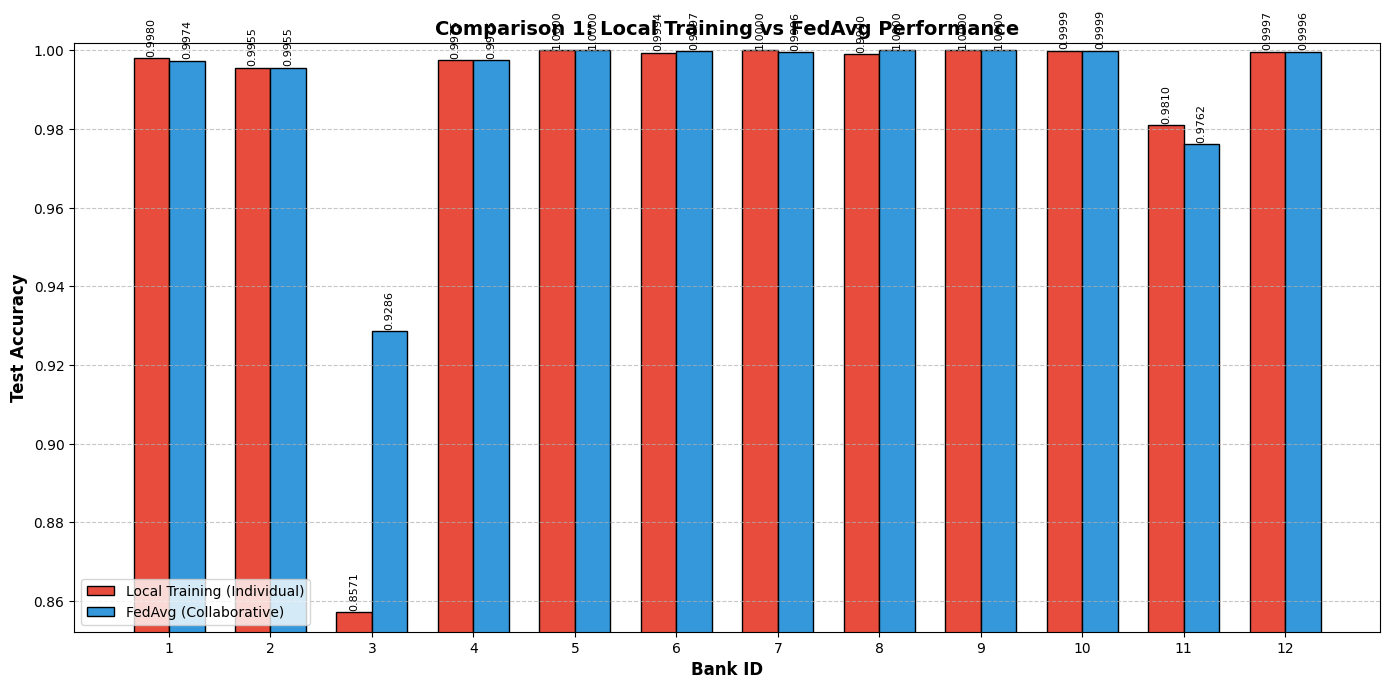

In [14]:
#Local Training vs FedAvg

import matplotlib.pyplot as plt
import numpy as np

banks = np.arange(1, NUM_CLIENTS + 1)
width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(banks - width/2, local_final_acc, width, label='Local Training (Individual)', color='#e74c3c', edgecolor='black')
plt.bar(banks + width/2, current_round_accs, width, label='FedAvg (Collaborative)', color='#3498db', edgecolor='black')

plt.xlabel('Bank ID', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Comparison 1: Local Training vs FedAvg Performance', fontsize=14, fontweight='bold')
plt.xticks(banks)


min_val = min(min(local_final_acc), min(current_round_accs))
plt.ylim(min_val - 0.005, 1.002)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(banks)):
    plt.text(banks[i] - width/2, local_final_acc[i] + 0.0005, f'{local_final_acc[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)
    plt.text(banks[i] + width/2, current_round_accs[i] + 0.0005, f'{current_round_accs[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

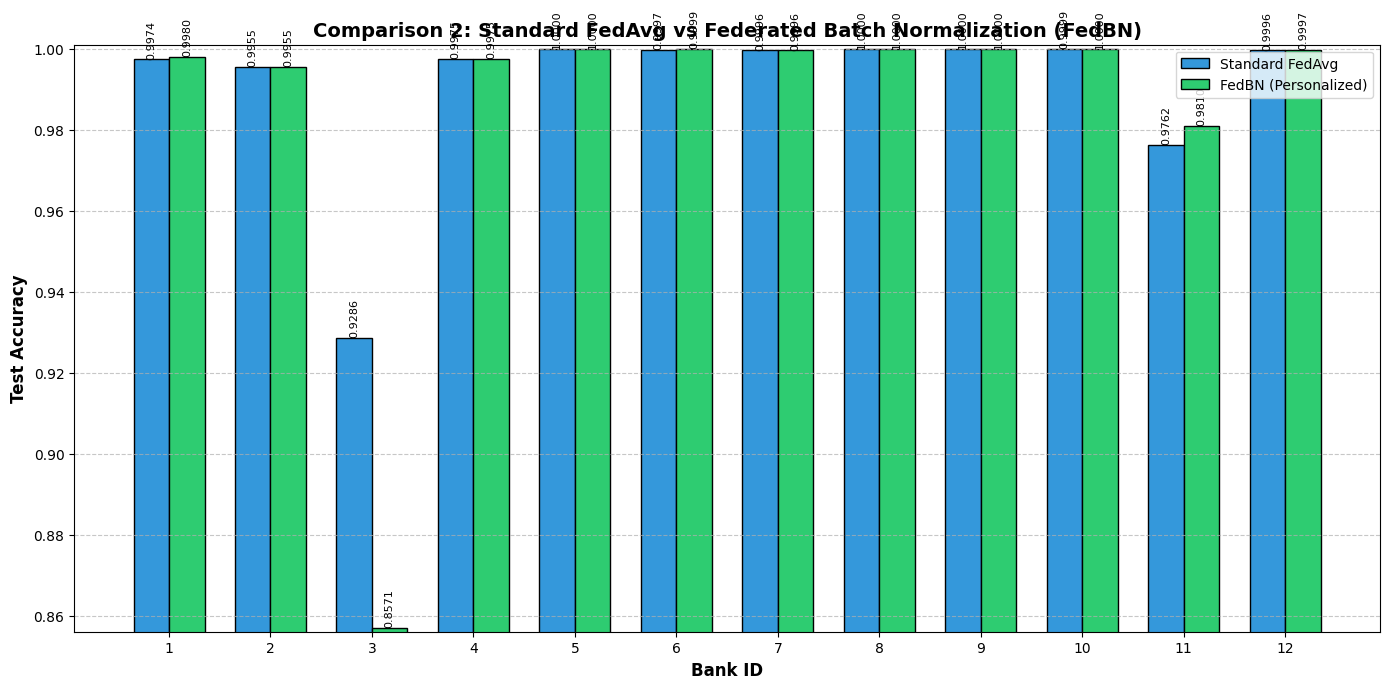

In [15]:
#FedAvg vs FedBN

import matplotlib.pyplot as plt
import numpy as np

banks = np.arange(1, NUM_CLIENTS + 1)
width = 0.35

plt.figure(figsize=(14, 7))


plt.bar(banks - width/2, current_round_accs, width, label='Standard FedAvg', color='#3498db', edgecolor='black')
plt.bar(banks + width/2, current_bn_accs, width, label='FedBN (Personalized)', color='#2ecc71', edgecolor='black')

plt.xlabel('Bank ID', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Comparison 2: Standard FedAvg vs Federated Batch Normalization (FedBN)', fontsize=14, fontweight='bold')
plt.xticks(banks)

min_val = min(min(current_round_accs), min(current_bn_accs))
plt.ylim(min_val - 0.001, 1.001)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(banks)):
    plt.text(banks[i] - width/2, current_round_accs[i] + 0.0001, f'{current_round_accs[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)
    plt.text(banks[i] + width/2, current_bn_accs[i] + 0.0001, f'{current_bn_accs[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

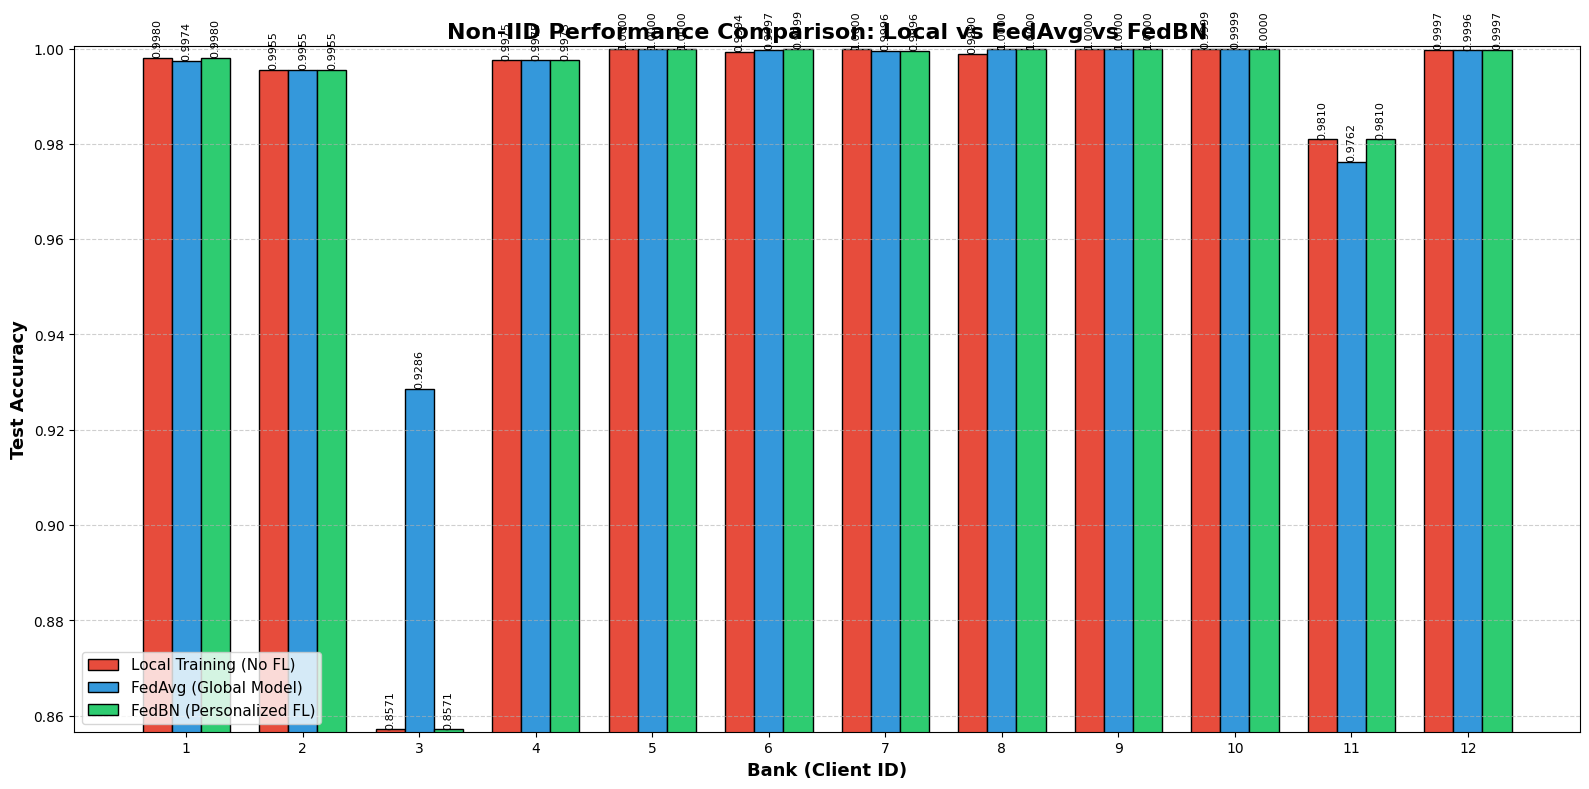

--------------------------------------------------
🔴 Local Avg  : 0.98560
🔵 FedAvg Avg : 0.99117
🟢 FedBN Avg  : 0.98569
--------------------------------------------------


In [16]:
import matplotlib.pyplot as plt
import numpy as np

banks = np.arange(1, NUM_CLIENTS + 1)
width = 0.25

plt.figure(figsize=(16, 8))

# 1. Local (Individual) Accuracy Bars
plt.bar(banks - width, local_final_acc, width, label='Local Training (No FL)', color='#e74c3c', edgecolor='black')

# 2. FedAvg Accuracy Bars
plt.bar(banks, current_round_accs, width, label='FedAvg (Global Model)', color='#3498db', edgecolor='black')

# 3. FedBN Accuracy Bars
plt.bar(banks + width, current_bn_accs, width, label='FedBN (Personalized FL)', color='#2ecc71', edgecolor='black')

# Graph
plt.xlabel('Bank (Client ID)', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=13, fontweight='bold')
plt.title('Non-IID Performance Comparison: Local vs FedAvg vs FedBN', fontsize=16, fontweight='bold')
plt.xticks(banks)

min_val = min(min(local_final_acc), min(current_round_accs), min(current_bn_accs))
plt.ylim(min_val - 0.0005, 1.0005)

plt.legend(loc='lower left', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)


for i in range(len(banks)):
    plt.text(banks[i] - width, local_final_acc[i] + 0.0001, f'{local_final_acc[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)
    plt.text(banks[i], current_round_accs[i] + 0.0001, f'{current_round_accs[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)
    plt.text(banks[i] + width, current_bn_accs[i] + 0.0001, f'{current_bn_accs[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

print("-" * 50)
print(f"🔴 Local Avg  : {np.mean(local_final_acc):.5f}")
print(f"🔵 FedAvg Avg : {np.mean(current_round_accs):.5f}")
print(f"🟢 FedBN Avg  : {np.mean(current_bn_accs):.5f}")
print("-" * 50)